# Optimal trade execution - Application on real data

We present the full pipeline used for the final evaluation.

This notebook implements a proper nested cross-validation procedure on real data for the optimal trade execution problem.

1. Outer folds (`test`) estimate generalization performance on multiple possible splits.
2. Inner folds*(`validation`) select the best state configuration without touching the outer test fold.
3. For each outer fold, the best configuration is **retrained on all non-test days**
   and evaluated on the outer test fold.
4. Final reporting aggregates performance across folds for a more stable estimate
   on a small dataset.

Main changes:
- no model selection on the test set;
- discretization bins are fit **inside each fold on training days only**;
- evaluation is repeated across several test splits;
- per-fold selected model and outer-test results are retained.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict, Counter
from itertools import combinations
from typing import Dict, Tuple, List, Optional



## Configuration

We start by defining the constants used throughout the notebook.


In [2]:
# Données
N_STOCKS = 3
N_DAYS = 5
ALL_DAYS = list(range(N_DAYS))

# Nested CV
OUTER_TEST_SIZE = 1      # leave-one-day-out test folds
INNER_VAL_SIZE = 1       # leave-one-day-out validation folds inside the outer-train set
MAX_OUTER_FOLDS = None   # set to an int to cap the number of outer folds
MAX_INNER_FOLDS = None   # set to an int to cap the number of inner folds

# Exécution
H_SEC = 120
T_STEPS = 8
DT = H_SEC / T_STEPS

V_TOTAL = 100
I_LEVELS = 10
TICK_SIZE = 0.01

# Discrétisation / backoff
N_IMB_BINS = 3
N_RET_BINS = 3

MIN_COUNT_EXACT = 3
MIN_COUNT_STOCK = 10
MIN_COUNT_GLOBAL = 25

# Actions RL
ACTION_SPECS = {
    "WAIT":    {"frac": 0.00, "type": "WAIT"},
    "MO_25":   {"frac": 0.25, "type": "MO"},
    "MO_50":   {"frac": 0.50, "type": "MO"},
    "MO_100":  {"frac": 1.00, "type": "MO"},
    "ASK_25":  {"frac": 0.25, "type": "ASK"},
    "ASK_50":  {"frac": 0.50, "type": "ASK"},
    "ASK_100": {"frac": 1.00, "type": "ASK"},
}
ACTIONS = list(ACTION_SPECS.keys())

STATE_CONFIGS = {
    "stock + inv only"      : [],
    "+ spread"              : ["spread_disc"],
    "+ imbalance"           : ["imb_disc"],
    "+ spread + imbalance"  : ["spread_disc", "imb_disc"],
    "+ spread + imb + ret"  : ["spread_disc", "imb_disc", "ret_disc"],
}



## Data loading

We load the raw update files and standardize timestamps.


In [3]:
def load_updates(n_stocks=N_STOCKS, n_days=N_DAYS):
    dfs = []
    for stock in range(n_stocks):
        for day in range(n_days):
            path = f"Data/stock{stock}_day{day}_updates.csv.gz"
            df = pd.read_csv(path, compression="gzip")
            df["stock"] = stock
            df["day"] = day
            dfs.append(df)

    updates = pd.concat(dfs, ignore_index=True)

    ts_num = pd.to_numeric(updates["ts"], errors="coerce")

    if ts_num.notna().all():
        updates["ts_raw"] = ts_num.astype("int64")

        raw_spans = (
            updates.groupby(["stock", "day"])["ts_raw"]
                   .agg(lambda x: float(x.max() - x.min()))
        )
        median_raw_span = float(raw_spans.median())

        if median_raw_span >= 1e13:
            inferred_unit = "ns"
            scale_to_seconds = 1e9
        elif median_raw_span >= 1e10:
            inferred_unit = "us"
            scale_to_seconds = 1e6
        elif median_raw_span >= 1e7:
            inferred_unit = "ms"
            scale_to_seconds = 1e3
        else:
            inferred_unit = "s"
            scale_to_seconds = 1.0

        updates = updates.sort_values(["stock", "day", "ts_raw"]).reset_index(drop=True)
        updates["ts_sec"] = (
            updates.groupby(["stock", "day"])["ts_raw"]
                   .transform(lambda x: (x - x.min()) / scale_to_seconds)
                   .astype(float)
        )

        updates.attrs["ts_mode"] = f"numeric/{inferred_unit}"
        updates.attrs["ts_scale_to_seconds"] = scale_to_seconds
        updates.attrs["median_raw_span"] = median_raw_span

    else:
        updates["ts"] = pd.to_datetime(updates["ts"], errors="coerce")
        updates = updates.dropna(subset=["ts"]).sort_values(["stock", "day", "ts"]).reset_index(drop=True)
        updates["ts_sec"] = (
            updates.groupby(["stock", "day"])["ts"]
                   .transform(lambda x: (x - x.min()).dt.total_seconds())
                   .astype(float)
        )

        updates.attrs["ts_mode"] = "datetime"
        updates.attrs["ts_scale_to_seconds"] = 1.0

    return updates


updates = load_updates()

print(f"Rows: {len(updates):,}")
print(f"Timestamp parsing mode: {updates.attrs.get('ts_mode', 'unknown')}")
if "median_raw_span" in updates.attrs:
    print(f"Median raw span across (stock, day): {updates.attrs['median_raw_span']:.0f}")

display(updates.groupby(["stock", "day"]).size().unstack(fill_value=0))



Rows: 4,705,051
Timestamp parsing mode: datetime


day,0,1,2,3,4
stock,,,,,
0,226217,338090,334977,468433,550083
1,73947,128253,139805,214988,201558
2,212731,365027,371879,491762,587301


## Causal L1 book and continuous causal features

We rebuild the L1 order book and compute causal features.


In [4]:
def prepare_book(updates: pd.DataFrame) -> pd.DataFrame:
    updates = updates.sort_values(["stock", "day", "ts_sec"]).copy()

    for col in ["bp", "ap", "bq", "aq"]:
        updates[f"{col}_f"] = updates.groupby(["stock", "day"])[col].ffill()

    book = updates.dropna(subset=["bp_f", "ap_f"]).copy()

    book["bq_f"] = book["bq_f"].fillna(0.0)
    book["aq_f"] = book["aq_f"].fillna(0.0)

    book = book[(book["ap_f"] > book["bp_f"]) & (book["bq_f"] >= 0) & (book["aq_f"] >= 0)].copy()

    book["mid"] = (book["bp_f"] + book["ap_f"]) / 2.0
    book["spread"] = book["ap_f"] - book["bp_f"]
    book["spread_ticks"] = np.maximum(1, np.round(book["spread"] / TICK_SIZE)).astype(int)

    denom = book["bq_f"] + book["aq_f"]
    book["imbalance"] = np.where(denom > 0, (book["bq_f"] - book["aq_f"]) / (denom + 1e-9), 0.0)
    book["event_type"] = book["type"].astype(str)

    return book.reset_index(drop=True)


def add_causal_features(ob: pd.DataFrame) -> pd.DataFrame:
    ob = ob.sort_values(["stock", "day", "ts_sec"]).copy()
    g = ob.groupby(["stock", "day"], group_keys=False)

    ob["mid_ret_1"] = g["mid"].diff().fillna(0.0)
    abs_ret = g["mid"].diff().abs().fillna(0.0)
    ob["abs_ret_30obs"] = (
        abs_ret.groupby([ob["stock"], ob["day"]])
               .transform(lambda x: x.rolling(window=30, min_periods=1).mean())
               .fillna(0.0)
    )
    ob["spread_disc"] = np.clip(ob["spread_ticks"], 1, 4) - 1
    return ob


ob_base = prepare_book(updates)
ob_base = add_causal_features(ob_base)

print(f"Rows retained for decision snapshots: {len(ob_base):,}")

coverage_df = (
    ob_base.groupby(["stock", "day"])
           .agg(n_rows=("ts_sec", "size"), t_start=("ts_sec", "min"), t_end=("ts_sec", "max"))
)
coverage_df["span_s"] = coverage_df["t_end"] - coverage_df["t_start"]

print("\nCoverage per (stock, day):")
display(coverage_df[["n_rows", "span_s"]].unstack(fill_value=0))



Rows retained for decision snapshots: 4,702,118

Coverage per (stock, day):


n_rows                                        span_s                \
day         0       1       2       3       4             0             1   
stock                                                                       
0      226128  337946  334854  468227  549738  30572.597315  30583.157192   
1       73581  128020  139555  214976  201514  30574.477783  30582.030305   
2      212559  364764  371752  491409  587095  30584.548869  30570.844902   

                                                 
day               2             3             4  
stock                                            
0      30576.132278  30586.320706  30576.590997  
1      30586.326783  30599.070250  30588.854969  
2      30589.326382  30574.219369  30580.192321

## Fold-specific discretization

We fit discretization bins on training days only.


In [5]:
def fit_quantile_bins(train_series: pd.Series, q: int = 3):
    s = train_series.dropna()
    if s.empty:
        return None
    bins = s.quantile(np.linspace(0, 1, q + 1)).values
    bins = np.unique(bins)
    if len(bins) < 2:
        return None
    bins[0] = -np.inf
    bins[-1] = np.inf
    return bins


def apply_bins(series: pd.Series, bins):
    if bins is None:
        return pd.Series(np.zeros(len(series), dtype=int), index=series.index)
    out = pd.cut(series, bins=bins, labels=False, include_lowest=True)
    return out.fillna(0).astype(int)


def discretize_features_by_train_days(ob: pd.DataFrame,
                                      train_days: List[int],
                                      n_imb_bins: int = N_IMB_BINS,
                                      n_ret_bins: int = N_RET_BINS) -> Tuple[pd.DataFrame, Dict]:
    ob = ob.copy()
    ob["imb_disc"] = -1
    ob["ret_disc"] = -1

    bins_by_stock = {}

    for stk in sorted(ob["stock"].unique()):
        m_train = (ob["stock"] == stk) & (ob["day"].isin(train_days))
        imb_bins = fit_quantile_bins(ob.loc[m_train, "imbalance"], q=n_imb_bins)
        ret_bins = fit_quantile_bins(ob.loc[m_train, "mid_ret_1"], q=n_ret_bins)

        bins_by_stock[int(stk)] = {
            "imb_bins": imb_bins,
            "ret_bins": ret_bins,
        }

        m_stock = ob["stock"] == stk
        ob.loc[m_stock, "imb_disc"] = apply_bins(ob.loc[m_stock, "imbalance"], imb_bins)
        ob.loc[m_stock, "ret_disc"] = apply_bins(ob.loc[m_stock, "mid_ret_1"], ret_bins)

    for col in ["spread_disc", "imb_disc", "ret_disc"]:
        ob[col] = ob[col].astype(int)

    return ob, bins_by_stock



## Episode construction

We convert each stock day into aligned execution episodes.


In [6]:
def build_episodes(ob_data: pd.DataFrame, days: List[int], H: float = H_SEC, T: int = T_STEPS):
    episodes = []

    for (stk, day), grp in ob_data[ob_data["day"].isin(days)].groupby(["stock", "day"]):
        grp = grp.sort_values("ts_sec").reset_index(drop=True)
        ts_vals = grp["ts_sec"].to_numpy(dtype=float)

        if len(ts_vals) < (T + 1):
            continue

        ts_start = float(ts_vals[0])
        ts_end = float(ts_vals[-1])
        span = ts_end - ts_start

        if span < H:
            continue

        n_windows = int(np.floor(span / H))

        for w in range(n_windows):
            t0 = ts_start + w * H

            snapshots = []
            valid = True

            for step in range(T + 1):
                t_target = t0 + step * (H / T)
                idx = np.searchsorted(ts_vals, t_target, side="right") - 1
                if idx < 0 or idx >= len(grp):
                    valid = False
                    break
                snapshots.append(grp.iloc[idx])

            if valid and len(snapshots) == T + 1:
                snap_times = [float(s["ts_sec"]) for s in snapshots]
                if len(set(snap_times)) >= 2:
                    episodes.append({
                        "stock": int(stk),
                        "day": int(day),
                        "t0_sec": float(t0),
                        "snapshots": snapshots,
                    })

    return episodes



## State space

We define the inventory state and the market state representation.


In [7]:
def inventory_level(remaining: float, total: float = V_TOTAL, n_levels: int = I_LEVELS) -> int:
    ratio = remaining / total
    return int(np.clip(np.round(ratio * n_levels), 0, n_levels))


def inventory_from_level(inv_level: int, total: float = V_TOTAL, n_levels: int = I_LEVELS) -> int:
    return int(np.round(inv_level / n_levels * total))


def state_key(stock: int, inv_level: int, snapshot: pd.Series, state_features: List[str]) -> Tuple[int, ...]:
    market = tuple(int(snapshot[f]) for f in state_features)
    return (int(stock), int(inv_level), *market)



## Execution simulator

We simulate how each child order would be executed.


In [8]:
def action_to_child_order(action_id: str, inventory: int) -> Tuple[int, str]:
    spec = ACTION_SPECS[action_id]
    order_type = spec["type"]

    if order_type == "WAIT" or inventory <= 0:
        return 0, "WAIT"

    qty = int(np.ceil(spec["frac"] * inventory))
    qty = max(1, qty)
    qty = min(qty, int(inventory))
    return qty, order_type


def simulate_sell_child_order(snapshot_start: pd.Series,
                              snapshot_end: pd.Series,
                              inventory: int,
                              child_qty: int,
                              order_type: str) -> Tuple[int, float, int]:
    child_qty = int(max(0, min(child_qty, inventory)))
    if inventory <= 0 or child_qty <= 0 or order_type == "WAIT":
        return 0, np.nan, inventory

    bp0 = float(snapshot_start["bp_f"])
    ap0 = float(snapshot_start["ap_f"])
    bp1 = float(snapshot_end["bp_f"])
    ap1 = float(snapshot_end["ap_f"])

    if order_type == "MO":
        exec_qty = child_qty
        exec_price = bp0
        return exec_qty, exec_price, inventory - exec_qty

    if order_type == "ASK":
        limit_price = ap0
        ask_level_cleared = (bp1 >= limit_price - 1e-12) or (ap1 > limit_price + 1e-12)
        if ask_level_cleared:
            exec_qty = child_qty
            exec_price = limit_price
            return exec_qty, exec_price, inventory - exec_qty
        return 0, np.nan, inventory

    raise ValueError(f"Unknown order_type={order_type}")


def step_cost_cash(snapshot_start: pd.Series,
                   snapshot_end: pd.Series,
                   exec_qty: int,
                   exec_price: float,
                   inv_after: int) -> float:
    mid_t = float(snapshot_start["mid"])
    mid_next = float(snapshot_end["mid"])
    exec_cost = 0.0 if exec_qty <= 0 else exec_qty * (mid_t - exec_price)
    hold_cost = inv_after * (mid_t - mid_next)
    return exec_cost + hold_cost


def terminal_market_cost_cash(snapshot_last: pd.Series, inventory: int) -> float:
    if inventory <= 0:
        return 0.0
    mid = float(snapshot_last["mid"])
    bid = float(snapshot_last["bp_f"])
    return inventory * (mid - bid)


def cost_cash_to_bps(total_cost_cash: float, arrival_mid: float, total_qty: int = V_TOTAL) -> float:
    notional = total_qty * arrival_mid
    return (total_cost_cash / notional) * 10_000.0



## Stores with backoff

We store value estimates with exact, stock, and global backoff levels.


In [9]:
def _state_to_stock_key(state: Tuple[int, ...]):
    stock = state[0]
    inv_level = state[1]
    return (stock, inv_level)


def _state_to_global_key(state: Tuple[int, ...]):
    inv_level = state[1]
    return (inv_level,)


def make_stat_store():
    return {
        "exact_sum": defaultdict(float),
        "exact_count": defaultdict(int),
        "stock_sum": defaultdict(float),
        "stock_count": defaultdict(int),
        "global_sum": defaultdict(float),
        "global_count": defaultdict(int),
    }


def add_stat(store, state: Tuple[int, ...], value: float):
    store["exact_sum"][state] += value
    store["exact_count"][state] += 1

    stock_key = _state_to_stock_key(state)
    store["stock_sum"][stock_key] += value
    store["stock_count"][stock_key] += 1

    global_key = _state_to_global_key(state)
    store["global_sum"][global_key] += value
    store["global_count"][global_key] += 1


def lookup_stat_mean(store,
                     state: Tuple[int, ...],
                     min_exact: int = MIN_COUNT_EXACT,
                     min_stock: int = MIN_COUNT_STOCK,
                     min_global: int = MIN_COUNT_GLOBAL) -> Tuple[Optional[float], str]:
    if store["exact_count"][state] >= min_exact:
        return store["exact_sum"][state] / store["exact_count"][state], "exact"

    stock_key = _state_to_stock_key(state)
    if store["stock_count"][stock_key] >= min_stock:
        return store["stock_sum"][stock_key] / store["stock_count"][stock_key], "stock"

    global_key = _state_to_global_key(state)
    if store["global_count"][global_key] >= min_global:
        return store["global_sum"][global_key] / store["global_count"][global_key], "global"

    return None, "fallback"


def make_q_store():
    return {
        "exact_sum": defaultdict(float),
        "exact_count": defaultdict(int),
        "stock_sum": defaultdict(float),
        "stock_count": defaultdict(int),
        "global_sum": defaultdict(float),
        "global_count": defaultdict(int),
    }


def add_q(store, state: Tuple[int, ...], action: str, q_value: float):
    exact_key = (state, action)
    store["exact_sum"][exact_key] += q_value
    store["exact_count"][exact_key] += 1

    stock_key = (_state_to_stock_key(state), action)
    store["stock_sum"][stock_key] += q_value
    store["stock_count"][stock_key] += 1

    global_key = (_state_to_global_key(state), action)
    store["global_sum"][global_key] += q_value
    store["global_count"][global_key] += 1


def lookup_q_mean(store,
                  state: Tuple[int, ...],
                  action: str,
                  min_exact: int = MIN_COUNT_EXACT,
                  min_stock: int = MIN_COUNT_STOCK,
                  min_global: int = MIN_COUNT_GLOBAL) -> Tuple[Optional[float], str]:
    exact_key = (state, action)
    if store["exact_count"][exact_key] >= min_exact:
        return store["exact_sum"][exact_key] / store["exact_count"][exact_key], "exact"

    stock_key = (_state_to_stock_key(state), action)
    if store["stock_count"][stock_key] >= min_stock:
        return store["stock_sum"][stock_key] / store["stock_count"][stock_key], "stock"

    global_key = (_state_to_global_key(state), action)
    if store["global_count"][global_key] >= min_global:
        return store["global_sum"][global_key] / store["global_count"][global_key], "global"

    return None, "fallback"



## Backward DP

We train the dynamic program by stepping backward in time.


In [10]:
def train_backward_dp(episodes_train: List[dict],
                      state_features: List[str],
                      actions: List[str] = ACTIONS):
    V_tables = {}
    Q_tables = {}
    backoff_counters = Counter()

    V0 = make_stat_store()
    for ep in episodes_train:
        snap_last = ep["snapshots"][-1]
        stk = ep["stock"]

        for inv_level in range(I_LEVELS + 1):
            inv = inventory_from_level(inv_level)
            state = state_key(stk, inv_level, snap_last, state_features)
            add_stat(V0, state, terminal_market_cost_cash(snap_last, inv))

    V_tables[0] = V0

    for t_rem in range(1, T_STEPS + 1):
        step_idx = T_STEPS - t_rem
        Q_t = make_q_store()

        for ep in episodes_train:
            stk = ep["stock"]
            snaps = ep["snapshots"]
            snap_cur = snaps[step_idx]
            snap_next = snaps[step_idx + 1]

            for inv_level in range(I_LEVELS + 1):
                inventory = inventory_from_level(inv_level)
                state = state_key(stk, inv_level, snap_cur, state_features)

                for action in actions:
                    child_qty, order_type = action_to_child_order(action, inventory)
                    exec_qty, exec_price, inv_after = simulate_sell_child_order(
                        snap_cur, snap_next, inventory, child_qty, order_type
                    )

                    immediate_cost = step_cost_cash(
                        snap_cur, snap_next, exec_qty, exec_price, inv_after
                    )

                    next_inv_level = inventory_level(inv_after)
                    next_state = state_key(stk, next_inv_level, snap_next, state_features)

                    future_cost, source = lookup_stat_mean(V_tables[t_rem - 1], next_state)
                    backoff_counters[(t_rem - 1, "V", source)] += 1
                    if future_cost is None:
                        future_cost = terminal_market_cost_cash(snap_next, inv_after)

                    add_q(Q_t, state, action, immediate_cost + future_cost)

        Q_tables[t_rem] = Q_t

        V_t = make_stat_store()
        seen_states = {state for (state, action) in Q_t["exact_count"].keys()}

        for state in seen_states:
            q_candidates = []
            for action in actions:
                q_mean, source = lookup_q_mean(Q_t, state, action)
                backoff_counters[(t_rem, "Q", source)] += 1
                if q_mean is not None:
                    q_candidates.append(q_mean)

            if q_candidates:
                add_stat(V_t, state, min(q_candidates))

        V_tables[t_rem] = V_t

    return V_tables, Q_tables, backoff_counters



## Policies and evaluation

We define the policies and the evaluation routine.


In [11]:
def choose_rl_action(stock: int,
                     t_rem: int,
                     inventory: int,
                     snapshot: pd.Series,
                     q_tables,
                     state_features: List[str]) -> Tuple[str, str]:
    inv_level = inventory_level(inventory)
    state = state_key(stock, inv_level, snapshot, state_features)

    q_values = {}
    sources = {}
    for action in ACTIONS:
        q_val, source = lookup_q_mean(q_tables[t_rem], state, action)
        q_values[action] = q_val
        sources[action] = source

    valid = {a: v for a, v in q_values.items() if v is not None}
    if valid:
        best = min(valid, key=valid.get)
        return best, sources[best]

    return ("MO_25" if t_rem > 1 else "MO_100"), "fallback"


def make_rl_policy(q_tables, state_features: List[str]):
    def _policy(stock, t_rem, inventory, snapshot, step_idx):
        action_id, _ = choose_rl_action(stock, t_rem, inventory, snapshot, q_tables, state_features)
        return action_to_child_order(action_id, inventory)
    return _policy


def immediate_market_policy(stock, t_rem, inventory, snapshot, step_idx):
    if step_idx == 0 and inventory > 0:
        return inventory, "MO"
    return 0, "WAIT"


def twap_market_policy(stock, t_rem, inventory, snapshot, step_idx):
    if inventory <= 0:
        return 0, "WAIT"
    target_remaining_next = int(np.round(V_TOTAL * (t_rem - 1) / T_STEPS))
    child_qty = max(0, inventory - target_remaining_next)
    return child_qty, "MO"


def twap_passive_ask_policy(stock, t_rem, inventory, snapshot, step_idx):
    if inventory <= 0:
        return 0, "WAIT"
    target_remaining_next = int(np.round(V_TOTAL * (t_rem - 1) / T_STEPS))
    child_qty = max(0, inventory - target_remaining_next)
    return child_qty, "ASK"


def wait_then_sweep_policy(stock, t_rem, inventory, snapshot, step_idx):
    if inventory <= 0:
        return 0, "WAIT"
    if t_rem <= 2:
        return inventory, "MO"
    return 0, "WAIT"


def rollout_episode(ep: dict, policy_fn) -> dict:
    snaps = ep["snapshots"]
    stock = ep["stock"]

    inventory = int(V_TOTAL)
    total_cost_cash = 0.0
    history = []

    for step_idx in range(T_STEPS):
        if inventory <= 0:
            break

        snap_cur = snaps[step_idx]
        snap_next = snaps[step_idx + 1]
        t_rem = T_STEPS - step_idx

        child_qty, order_type = policy_fn(stock, t_rem, inventory, snap_cur, step_idx)
        exec_qty, exec_price, inv_after = simulate_sell_child_order(
            snap_cur, snap_next, inventory, child_qty, order_type
        )

        step_cost = step_cost_cash(snap_cur, snap_next, exec_qty, exec_price, inv_after)
        total_cost_cash += step_cost

        history.append({
            "step": step_idx,
            "t_rem": t_rem,
            "inventory_before": inventory,
            "child_qty": child_qty,
            "order_type": order_type,
            "exec_qty": exec_qty,
            "exec_price": exec_price,
            "inventory_after": inv_after,
            "step_cost_cash": step_cost,
        })

        inventory = inv_after

    if inventory > 0:
        total_cost_cash += terminal_market_cost_cash(snaps[-1], inventory)

    arrival_mid = float(snaps[0]["mid"])
    total_cost_bps = cost_cash_to_bps(total_cost_cash, arrival_mid, total_qty=V_TOTAL)

    return {
        "stock": stock,
        "day": ep["day"],
        "cost_cash": total_cost_cash,
        "cost_bps": total_cost_bps,
        "history": history,
    }


def evaluate_policy(episodes: List[dict], policy_fn, label: str, verbose: bool = True):
    if len(episodes) == 0:
        if verbose:
            print(f"{label:28s} -> mean =     nan bps | std =     nan | N = 0")
        return {
            "label": label,
            "mean_bps": np.nan,
            "std_bps": np.nan,
            "median_bps": np.nan,
            "n_episodes": 0,
            "costs_bps": np.array([], dtype=float),
            "outputs": [],
        }

    outputs = [rollout_episode(ep, policy_fn) for ep in episodes]
    costs = np.array([o["cost_bps"] for o in outputs], dtype=float)

    if verbose:
        print(f"{label:28s} -> mean = {costs.mean():7.3f} bps | std = {costs.std():7.3f} | N = {len(costs)}")

    return {
        "label": label,
        "mean_bps": float(costs.mean()),
        "std_bps": float(costs.std()),
        "median_bps": float(np.median(costs)),
        "n_episodes": int(len(costs)),
        "costs_bps": costs,
        "outputs": outputs,
    }



## Nested CV helpers

We add helper functions for the nested cross validation workflow.


In [12]:
def generate_day_folds(days: List[int], test_size: int = 1, max_folds: Optional[int] = None) -> List[Tuple[int, ...]]:
    folds = list(combinations(sorted(days), test_size))
    if max_folds is not None:
        folds = folds[:max_folds]
    return [tuple(int(x) for x in fold) for fold in folds]


def safe_mean(x):
    x = pd.Series(x).dropna()
    return np.nan if len(x) == 0 else float(x.mean())


def run_single_split(ob_base: pd.DataFrame,
                     train_days: List[int],
                     eval_days: List[int],
                     state_label: str,
                     state_features: List[str]) -> Dict:
    ob_fold, bins_info = discretize_features_by_train_days(ob_base, train_days=train_days)

    episodes_train = build_episodes(ob_fold, days=train_days)
    episodes_eval = build_episodes(ob_fold, days=eval_days)

    if len(episodes_train) == 0:
        return {
            "state_config": state_label,
            "features": tuple(state_features),
            "train_days": tuple(train_days),
            "eval_days": tuple(eval_days),
            "train_episodes": 0,
            "eval_episodes": len(episodes_eval),
            "V_tables": None,
            "Q_tables": None,
            "backoff": None,
            "eval": {
                "label": state_label,
                "mean_bps": np.nan,
                "std_bps": np.nan,
                "median_bps": np.nan,
                "n_episodes": len(episodes_eval),
                "costs_bps": np.array([], dtype=float),
                "outputs": [],
            },
            "bins_info": bins_info,
        }

    V_tab, Q_tab, backoff_tab = train_backward_dp(
        episodes_train=episodes_train,
        state_features=state_features,
        actions=ACTIONS,
    )

    rl_policy = make_rl_policy(Q_tab, state_features)
    res = evaluate_policy(episodes_eval, rl_policy, state_label, verbose=False)

    return {
        "state_config": state_label,
        "features": tuple(state_features),
        "train_days": tuple(train_days),
        "eval_days": tuple(eval_days),
        "train_episodes": len(episodes_train),
        "eval_episodes": len(episodes_eval),
        "V_tables": V_tab,
        "Q_tables": Q_tab,
        "backoff": backoff_tab,
        "eval": res,
        "bins_info": bins_info,
    }


def select_best_state_config_inner_cv(ob_base: pd.DataFrame,
                                      outer_train_days: List[int]) -> Tuple[pd.DataFrame, str, List[str]]:
    inner_val_folds = generate_day_folds(
        days=outer_train_days,
        test_size=INNER_VAL_SIZE,
        max_folds=MAX_INNER_FOLDS,
    )

    rows = []

    for inner_val_days in inner_val_folds:
        inner_train_days = [d for d in outer_train_days if d not in inner_val_days]

        for label, features in STATE_CONFIGS.items():
            split_res = run_single_split(
                ob_base=ob_base,
                train_days=inner_train_days,
                eval_days=list(inner_val_days),
                state_label=label,
                state_features=features,
            )

            rows.append({
                "state_config": label,
                "features": tuple(features),
                "inner_train_days": tuple(inner_train_days),
                "inner_val_days": tuple(inner_val_days),
                "train_episodes": split_res["train_episodes"],
                "val_episodes": split_res["eval_episodes"],
                "val_mean_bps": split_res["eval"]["mean_bps"],
                "val_std_bps": split_res["eval"]["std_bps"],
                "val_median_bps": split_res["eval"]["median_bps"],
            })

    inner_df = pd.DataFrame(rows)

    summary_df = (
        inner_df.groupby(["state_config", "features"], as_index=False)
                .agg(
                    n_inner_folds=("val_mean_bps", "size"),
                    mean_val_bps=("val_mean_bps", safe_mean),
                    std_val_bps=("val_mean_bps", lambda x: float(pd.Series(x).dropna().std()) if pd.Series(x).dropna().size > 1 else np.nan),
                    median_val_bps=("val_mean_bps", lambda x: float(pd.Series(x).dropna().median()) if pd.Series(x).dropna().size > 0 else np.nan),
                    total_val_episodes=("val_episodes", "sum"),
                )
                .sort_values(
                    ["mean_val_bps", "median_val_bps", "std_val_bps", "state_config"],
                    na_position="last"
                )
                .reset_index(drop=True)
    )

    if summary_df.empty or summary_df["mean_val_bps"].dropna().empty:
        return summary_df, None, None

    best_label = str(summary_df.iloc[0]["state_config"])
    best_features = list(STATE_CONFIGS[best_label])
    return summary_df, best_label, best_features



## Nested train/val/test K-fold procedure

We run the full nested cross validation procedure.


In [13]:
outer_test_folds = generate_day_folds(
    days=ALL_DAYS,
    test_size=OUTER_TEST_SIZE,
    max_folds=MAX_OUTER_FOLDS,
)

print("═" * 80)
print("NESTED CROSS-VALIDATION")
print("═" * 80)
print(f"All days          : {ALL_DAYS}")
print(f"Outer test folds  : {outer_test_folds}")
print(f"Inner val size    : {INNER_VAL_SIZE}")
print()

outer_fold_results = []
inner_selection_tables = {}
outer_test_strategy_rows = []
outer_test_episode_level_rows = []

for outer_idx, outer_test_days in enumerate(outer_test_folds, start=1):
    outer_test_days = list(outer_test_days)
    outer_train_days = [d for d in ALL_DAYS if d not in outer_test_days]

    print("-" * 80)
    print(f"Outer fold {outer_idx}/{len(outer_test_folds)}")
    print(f"  outer train days : {outer_train_days}")
    print(f"  outer test days  : {outer_test_days}")

    inner_summary_df, best_label, best_features = select_best_state_config_inner_cv(
        ob_base=ob_base,
        outer_train_days=outer_train_days,
    )
    inner_selection_tables[outer_idx] = inner_summary_df

    print("  Inner-CV ranking:")
    display(inner_summary_df.round(4) if not inner_summary_df.empty else inner_summary_df)

    if best_label is None:
        print("  No selectable model for this outer fold.")
        outer_fold_results.append({
            "outer_fold": outer_idx,
            "outer_train_days": tuple(outer_train_days),
            "outer_test_days": tuple(outer_test_days),
            "best_state_config": None,
            "best_features": None,
            "train_episodes": 0,
            "test_episodes": 0,
            "rl_mean_bps": np.nan,
            "rl_std_bps": np.nan,
            "rl_median_bps": np.nan,
        })
        continue

    print(f"  Selected config  : {best_label}")
    print(f"  Selected features: {best_features}")

    final_split = run_single_split(
        ob_base=ob_base,
        train_days=outer_train_days,
        eval_days=outer_test_days,
        state_label=best_label,
        state_features=best_features,
    )

    rl_policy_best = make_rl_policy(final_split["Q_tables"], best_features)

    ob_outer, _ = discretize_features_by_train_days(ob_base, train_days=outer_train_days)
    episodes_test_outer = build_episodes(ob_outer, days=outer_test_days)

    res_rl_best = evaluate_policy(episodes_test_outer, rl_policy_best, f"RL ({best_label})", verbose=True)
    res_immediate = evaluate_policy(episodes_test_outer, immediate_market_policy, "Immediate Market", verbose=True)
    res_twap_mo = evaluate_policy(episodes_test_outer, twap_market_policy, "TWAP-MO", verbose=True)
    res_twap_ask = evaluate_policy(episodes_test_outer, twap_passive_ask_policy, "TWAP-PassiveAsk", verbose=True)
    res_wait_sweep = evaluate_policy(episodes_test_outer, wait_then_sweep_policy, "Wait-then-Sweep", verbose=True)

    outer_fold_results.append({
        "outer_fold": outer_idx,
        "outer_train_days": tuple(outer_train_days),
        "outer_test_days": tuple(outer_test_days),
        "best_state_config": best_label,
        "best_features": tuple(best_features),
        "train_episodes": final_split["train_episodes"],
        "test_episodes": len(episodes_test_outer),
        "rl_mean_bps": res_rl_best["mean_bps"],
        "rl_std_bps": res_rl_best["std_bps"],
        "rl_median_bps": res_rl_best["median_bps"],
    })

    for strat_res in [res_rl_best, res_immediate, res_twap_mo, res_twap_ask, res_wait_sweep]:
        outer_test_strategy_rows.append({
            "outer_fold": outer_idx,
            "outer_test_days": tuple(outer_test_days),
            "strategy": strat_res["label"],
            "mean_bps": strat_res["mean_bps"],
            "std_bps": strat_res["std_bps"],
            "median_bps": strat_res["median_bps"],
            "n_episodes": strat_res["n_episodes"],
        })

        for cost in strat_res["costs_bps"]:
            outer_test_episode_level_rows.append({
                "outer_fold": outer_idx,
                "outer_test_days": tuple(outer_test_days),
                "strategy": strat_res["label"],
                "cost_bps": float(cost),
            })



════════════════════════════════════════════════════════════════════════════════
NESTED CROSS-VALIDATION
════════════════════════════════════════════════════════════════════════════════
All days          : [0, 1, 2, 3, 4]
Outer test folds  : [(0,), (1,), (2,), (3,), (4,)]
Inner val size    : 1

--------------------------------------------------------------------------------
Outer fold 1/5
  outer train days : [1, 2, 3, 4]
  outer test days  : [0]
  Inner-CV ranking:


,state_config,features,n_inner_folds,mean_val_bps,std_val_bps,median_val_bps,total_val_episodes
0,+ spread + imb + ret,"(spread_disc, imb_disc, ret_disc)",4,1.4229,0.3890,1.4493,3048
1,+ imbalance,"(imb_disc,)",4,1.4496,0.2264,1.4096,3048
2,+ spread,"(spread_disc,)",4,1.4999,0.2732,1.5392,3048
3,+ spread + imbalance,"(spread_disc, imb_disc)",4,1.5074,0.3621,1.4756,3048
4,stock + inv only,(),4,1.6678,0.2714,1.6409,3048


  Selected config  : + spread + imb + ret
  Selected features: ['spread_disc', 'imb_disc', 'ret_disc']
RL (+ spread + imb + ret)    -> mean =   0.988 bps | std =   6.750 | N = 762
Immediate Market             -> mean =   1.591 bps | std =   1.115 | N = 762
TWAP-MO                      -> mean =   1.482 bps | std =   4.097 | N = 762
TWAP-PassiveAsk              -> mean =   1.183 bps | std =   6.051 | N = 762
Wait-then-Sweep              -> mean =   1.378 bps | std =   6.707 | N = 762
--------------------------------------------------------------------------------
Outer fold 2/5
  outer train days : [0, 2, 3, 4]
  outer test days  : [1]
  Inner-CV ranking:


,state_config,features,n_inner_folds,mean_val_bps,std_val_bps,median_val_bps,total_val_episodes
0,+ spread + imbalance,"(spread_disc, imb_disc)",4,1.3876,0.6498,1.2343,3048
1,+ spread + imb + ret,"(spread_disc, imb_disc, ret_disc)",4,1.3953,0.5031,1.3151,3048
2,+ imbalance,"(imb_disc,)",4,1.4024,0.1832,1.4221,3048
3,+ spread,"(spread_disc,)",4,1.4069,0.2660,1.3990,3048
4,stock + inv only,(),4,1.5559,0.2085,1.5824,3048


  Selected config  : + spread + imbalance
  Selected features: ['spread_disc', 'imb_disc']
RL (+ spread + imbalance)    -> mean =   1.196 bps | std =   8.086 | N = 762
Immediate Market             -> mean =   1.752 bps | std =   1.474 | N = 762
TWAP-MO                      -> mean =   1.696 bps | std =   4.916 | N = 762
TWAP-PassiveAsk              -> mean =   1.800 bps | std =   7.151 | N = 762
Wait-then-Sweep              -> mean =   1.758 bps | std =   8.178 | N = 762
--------------------------------------------------------------------------------
Outer fold 3/5
  outer train days : [0, 1, 3, 4]
  outer test days  : [2]
  Inner-CV ranking:


...

  Selected config  : + imbalance
  Selected features: ['imb_disc']
RL (+ imbalance)             -> mean =   1.252 bps | std =   3.882 | N = 762
Immediate Market             -> mean =   1.684 bps | std =   1.321 | N = 762
TWAP-MO                      -> mean =   1.251 bps | std =   5.448 | N = 762
TWAP-PassiveAsk              -> mean =   1.254 bps | std =   7.618 | N = 762
Wait-then-Sweep              -> mean =   1.179 bps | std =   8.729 | N = 762
--------------------------------------------------------------------------------
Outer fold 4/5
  outer train days : [0, 1, 2, 4]
  outer test days  : [3]
  Inner-CV ranking:


,state_config,features,n_inner_folds,mean_val_bps,std_val_bps,median_val_bps,total_val_episodes
0,+ spread + imb + ret,"(spread_disc, imb_disc, ret_disc)",4,1.2797,0.4761,1.1291,3048
1,+ spread + imbalance,"(spread_disc, imb_disc)",4,1.3128,0.6081,1.0906,3048
2,+ spread,"(spread_disc,)",4,1.3634,0.1992,1.3207,3048
3,+ imbalance,"(imb_disc,)",4,1.3903,0.2089,1.3185,3048
4,stock + inv only,(),4,1.5978,0.2014,1.5123,3048


  Selected config  : + spread + imb + ret
  Selected features: ['spread_disc', 'imb_disc', 'ret_disc']
RL (+ spread + imb + ret)    -> mean =   1.632 bps | std =  11.089 | N = 762
Immediate Market             -> mean =   1.927 bps | std =   1.008 | N = 762
TWAP-MO                      -> mean =   2.170 bps | std =   6.709 | N = 762
TWAP-PassiveAsk              -> mean =   2.328 bps | std =   9.274 | N = 762
Wait-then-Sweep              -> mean =   2.092 bps | std =  10.915 | N = 762
--------------------------------------------------------------------------------
Outer fold 5/5
  outer train days : [0, 1, 2, 3]
  outer test days  : [4]
  Inner-CV ranking:


,state_config,features,n_inner_folds,mean_val_bps,std_val_bps,median_val_bps,total_val_episodes
0,+ spread + imb + ret,"(spread_disc, imb_disc, ret_disc)",4,1.2020,0.3738,1.1202,3048
1,+ spread + imbalance,"(spread_disc, imb_disc)",4,1.2569,0.3887,1.1809,3048
2,+ imbalance,"(imb_disc,)",4,1.3566,0.2069,1.2713,3048
3,+ spread,"(spread_disc,)",4,1.3676,0.1986,1.3451,3048
4,stock + inv only,(),4,1.5193,0.2420,1.4400,3048


  Selected config  : + spread + imb + ret
  Selected features: ['spread_disc', 'imb_disc', 'ret_disc']
RL (+ spread + imb + ret)    -> mean =   1.880 bps | std =  10.312 | N = 762
Immediate Market             -> mean =   1.755 bps | std =   1.285 | N = 762
TWAP-MO                      -> mean =   2.180 bps | std =   7.124 | N = 762
TWAP-PassiveAsk              -> mean =   3.039 bps | std =   9.954 | N = 762
Wait-then-Sweep              -> mean =   2.230 bps | std =  11.488 | N = 762


## Outer-fold selection summary

We summarize which state configuration was selected across folds.


In [14]:
outer_folds_df = pd.DataFrame(outer_fold_results)
display(outer_folds_df)

if not outer_folds_df.empty:
    print("Selected configuration frequency across outer folds:")
    display(
        outer_folds_df["best_state_config"]
            .value_counts(dropna=False)
            .rename_axis("state_config")
            .reset_index(name="n_outer_folds")
    )



,outer_fold,outer_train_days,outer_test_days,best_state_config,best_features,train_episodes,test_episodes,rl_mean_bps,rl_std_bps,rl_median_bps
0,1,"(1, 2, 3, 4)","(0,)",+ spread + imb + ret,"(spread_disc, imb_disc, ret_disc)",3048,762,0.988310,6.750388,0.903506
1,2,"(0, 2, 3, 4)","(1,)",+ spread + imbalance,"(spread_disc, imb_disc)",3048,762,1.196385,8.085868,0.949487
2,3,"(0, 1, 3, 4)","(2,)",+ imbalance,"(imb_disc,)",3048,762,1.252253,3.882104,0.960707
3,4,"(0, 1, 2, 4)","(3,)",+ spread + imb + ret,"(spread_disc, imb_disc, ret_disc)",3048,762,1.632046,11.089450,0.968176
4,5,"(0, 1, 2, 3)","(4,)",+ spread + imb + ret,"(spread_disc, imb_disc, ret_disc)",3048,762,1.879669,10.311606,1.004571


Selected configuration frequency across outer folds:


,state_config,n_outer_folds
0,+ spread + imb + ret,3
1,+ spread + imbalance,1
2,+ imbalance,1


## Aggregated outer-test performance

We aggregate outer test performance across all strategies.


In [15]:
outer_test_results_df = pd.DataFrame(outer_test_strategy_rows)
outer_test_episode_df = pd.DataFrame(outer_test_episode_level_rows)

display(outer_test_results_df.round(4))

if not outer_test_results_df.empty:
    outer_agg_df = (
        outer_test_results_df.groupby("strategy", as_index=False)
                             .agg(
                                 mean_of_fold_means=("mean_bps", "mean"),
                                 std_of_fold_means=("mean_bps", "std"),
                                 median_of_fold_means=("mean_bps", "median"),
                                 total_test_episodes=("n_episodes", "sum"),
                                 n_outer_folds=("outer_fold", "nunique"),
                             )
                             .sort_values("mean_of_fold_means", na_position="last")
                             .reset_index(drop=True)
    )
    display(outer_agg_df.round(4))

    if not outer_test_episode_df.empty:
        pooled_episode_agg_df = (
            outer_test_episode_df.groupby("strategy", as_index=False)
                                 .agg(
                                     pooled_mean_bps=("cost_bps", "mean"),
                                     pooled_std_bps=("cost_bps", "std"),
                                     pooled_median_bps=("cost_bps", "median"),
                                     pooled_n=("cost_bps", "size"),
                                 )
                                 .sort_values("pooled_mean_bps", na_position="last")
                                 .reset_index(drop=True)
        )
        print("Pooled episode-level performance across all outer test folds:")
        display(pooled_episode_agg_df.round(4))



,outer_fold,outer_test_days,strategy,mean_bps,std_bps,median_bps,n_episodes
0,1,"(0,)",RL (+ spread + imb + ret),0.9883,6.7504,0.9035,762
1,1,"(0,)",Immediate Market,1.5906,1.1154,0.9458,762
2,1,"(0,)",TWAP-MO,1.4816,4.0972,1.3653,762
3,1,"(0,)",TWAP-PassiveAsk,1.1835,6.0514,0.7095,762
4,1,"(0,)",Wait-then-Sweep,1.3780,6.7073,0.9360,762
5,2,"(1,)",RL (+ spread + imbalance),1.1964,8.0859,0.9495,762
6,2,"(1,)",Immediate Market,1.7524,1.4738,1.8065,762
7,2,"(1,)",TWAP-MO,1.6963,4.9157,1.6398,762
8,2,"(1,)",TWAP-PassiveAsk,1.8000,7.1510,0.9510,762
9,2,"(1,)",Wait-then-Sweep,1.7581,8.1782,0.9550,762


,strategy,mean_of_fold_means,std_of_fold_means,median_of_fold_means,total_test_episodes,n_outer_folds
0,RL (+ spread + imbalance),1.1964,NaN,1.1964,762,1
1,RL (+ imbalance),1.2523,NaN,1.2523,762,1
2,RL (+ spread + imb + ret),1.5000,0.4601,1.6320,2286,3
3,Wait-then-Sweep,1.7275,0.4497,1.7581,3810,5
4,Immediate Market,1.7417,0.1235,1.7524,3810,5
5,TWAP-MO,1.7558,0.4138,1.6963,3810,5
6,TWAP-PassiveAsk,1.9209,0.7776,1.8000,3810,5


Pooled episode-level performance across all outer test folds:


,strategy,pooled_mean_bps,pooled_std_bps,pooled_median_bps,pooled_n
0,RL (+ spread + imbalance),1.1964,8.0912,0.9495,762
1,RL (+ imbalance),1.2523,3.8847,0.9607,762
2,RL (+ spread + imb + ret),1.5000,9.5815,0.9351,2286
3,Wait-then-Sweep,1.7275,9.3820,0.9606,3810
4,Immediate Market,1.7417,1.2564,1.7905,3810
5,TWAP-MO,1.7558,5.7814,1.5653,3810
6,TWAP-PassiveAsk,1.9209,8.1658,0.9584,3810


## Recommended final model choice after nested CV

We pick the final state configuration from the nested CV results.


In [16]:
if outer_folds_df.empty or outer_folds_df["best_state_config"].dropna().empty:
    RECOMMENDED_FINAL_STATE_LABEL = None
    RECOMMENDED_FINAL_STATE_FEATURES = None
    print("No recommended final configuration could be determined.")
else:
    selection_counts = (
        outer_folds_df.dropna(subset=["best_state_config"])
                      .groupby("best_state_config", as_index=False)
                      .agg(
                          n_selected=("outer_fold", "size"),
                          avg_outer_rl_mean_bps=("rl_mean_bps", "mean"),
                      )
                      .sort_values(["n_selected", "avg_outer_rl_mean_bps"], ascending=[False, True])
                      .reset_index(drop=True)
    )

    RECOMMENDED_FINAL_STATE_LABEL = str(selection_counts.iloc[0]["best_state_config"])
    RECOMMENDED_FINAL_STATE_FEATURES = list(STATE_CONFIGS[RECOMMENDED_FINAL_STATE_LABEL])

    print(f"Recommended final state config : {RECOMMENDED_FINAL_STATE_LABEL}")
    print(f"Recommended final features     : {RECOMMENDED_FINAL_STATE_FEATURES}")
    display(selection_counts.round(4))



Recommended final state config : + spread + imb + ret
Recommended final features     : ['spread_disc', 'imb_disc', 'ret_disc']


,best_state_config,n_selected,avg_outer_rl_mean_bps
0,+ spread + imb + ret,3,1.5000
1,+ spread + imbalance,1,1.1964
2,+ imbalance,1,1.2523


## Final refit on all days

We refit the selected model on the full dataset.


In [17]:
if RECOMMENDED_FINAL_STATE_LABEL is None:
    FINAL_ALL_DATA_Q_TABLES = None
    FINAL_ALL_DATA_V_TABLES = None
    FINAL_ALL_DATA_BACKOFF = None
else:
    ob_all, _ = discretize_features_by_train_days(ob_base, train_days=ALL_DAYS)
    episodes_all = build_episodes(ob_all, days=ALL_DAYS)

    if len(episodes_all) == 0:
        FINAL_ALL_DATA_Q_TABLES = None
        FINAL_ALL_DATA_V_TABLES = None
        FINAL_ALL_DATA_BACKOFF = None
        print("No episodes available for the all-data refit.")
    else:
        FINAL_ALL_DATA_V_TABLES, FINAL_ALL_DATA_Q_TABLES, FINAL_ALL_DATA_BACKOFF = train_backward_dp(
            episodes_train=episodes_all,
            state_features=RECOMMENDED_FINAL_STATE_FEATURES,
            actions=ACTIONS,
        )
        print(f"All-data refit done with config: {RECOMMENDED_FINAL_STATE_LABEL}")
        print(f"Number of all-data episodes   : {len(episodes_all)}")



All-data refit done with config: + spread + imb + ret
Number of all-data episodes   : 3810


## Diagnostics of the all-data refit

We inspect coverage and backoff diagnostics for the final refit.


In [18]:
if 'FINAL_ALL_DATA_Q_TABLES' not in globals() or FINAL_ALL_DATA_Q_TABLES is None:
    print("No all-data diagnostics available.")
else:
    obs_counts = np.array(list(FINAL_ALL_DATA_Q_TABLES[T_STEPS]["exact_count"].values()), dtype=float)

    print("Observations per (state, action) at the longest horizon:")
    if len(obs_counts) == 0:
        print("  none")
    else:
        print(f"  median         : {np.median(obs_counts):.0f}")
        print(f"  % with < 3 obs : {100*np.mean(obs_counts < 3):.1f}%")
        print(f"  % with < 5 obs : {100*np.mean(obs_counts < 5):.1f}%")
        print(f"  % with <10 obs : {100*np.mean(obs_counts < 10):.1f}%")

    if FINAL_ALL_DATA_BACKOFF is None or len(FINAL_ALL_DATA_BACKOFF) == 0:
        print("\\nNo backoff diagnostics available.")
    else:
        backoff_df = pd.DataFrame([
            {"t_rem": k[0], "table": k[1], "source": k[2], "count": v}
            for k, v in FINAL_ALL_DATA_BACKOFF.items()
        ]).sort_values(["table", "t_rem", "source"])
        display(backoff_df.head(20))



Observations per (state, action) at the longest horizon:
  median         : 8
  % with < 3 obs : 23.1%
  % with < 5 obs : 34.6%
  % with <10 obs : 53.8%


,t_rem,table,source,count
2,1,Q,exact,3003
3,1,Q,stock,1309
5,2,Q,exact,2926
6,2,Q,stock,1001
8,3,Q,exact,3003
9,3,Q,stock,924
11,4,Q,exact,3388
12,4,Q,stock,847
14,5,Q,exact,3003
15,5,Q,stock,1078


## Fold-performance visualization

We visualize how each strategy performs across outer folds.


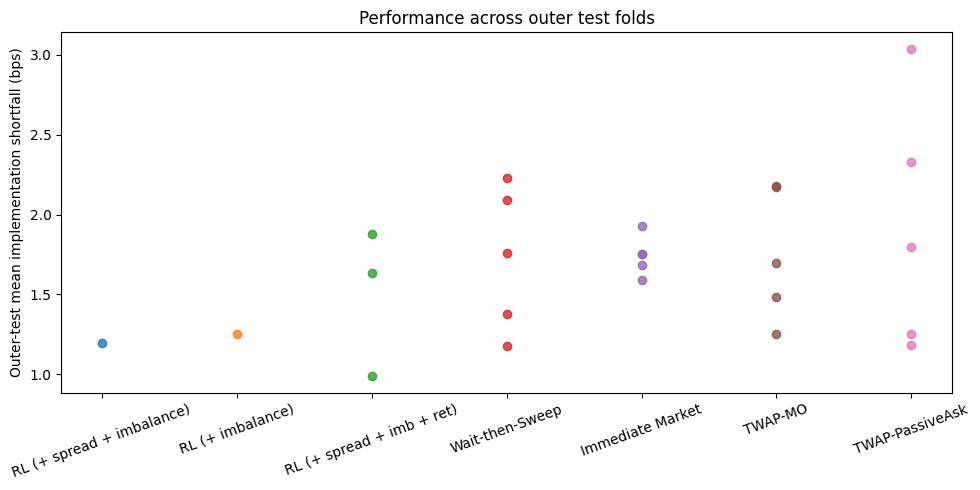

In [19]:
if not outer_test_results_df.empty:
    plt.figure(figsize=(10, 5))
    plot_df = outer_test_results_df.copy()
    order = (
        plot_df.groupby("strategy")["mean_bps"]
               .mean()
               .sort_values()
               .index.tolist()
    )

    for strategy in order:
        y = plot_df.loc[plot_df["strategy"] == strategy, "mean_bps"].to_numpy()
        x = np.full_like(y, fill_value=order.index(strategy), dtype=float)
        plt.scatter(x, y, alpha=0.8, label=strategy)

    plt.xticks(range(len(order)), order, rotation=20)
    plt.ylabel("Outer-test mean implementation shortfall (bps)")
    plt.title("Performance across outer test folds")
    plt.tight_layout()
    plt.show()



## Baseline comparison on pooled outer-test episodes

We compare the RL policy against the main baseline on pooled test episodes.


,strategy,n
0,Immediate Market,3810
1,RL (+ imbalance),762
2,RL (+ spread + imb + ret),2286
3,RL (+ spread + imbalance),762
4,TWAP-MO,3810
5,TWAP-PassiveAsk,3810
6,Wait-then-Sweep,3810


Convention: diff = cost(Immediate) - cost(RL)
diff > 0 means RL is better
N pooled episodes          : 3810
Mean gain of RL (bps)      : 0.3520
Median gain of RL (bps)    : 0.0000
% episodes RL better       : 43.52%
Bootstrap 95% CI of gain   : [0.0842, 0.6220] bps
Paired t-test p-value      : 0.00564153
Wilcoxon signed-rank p     : 0.000143376


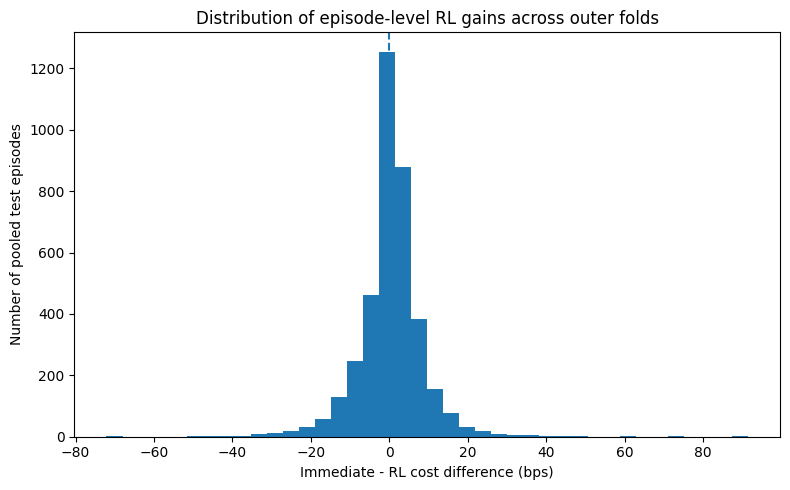

In [20]:
if not outer_test_episode_df.empty:
    pivot_counts = (
        outer_test_episode_df.groupby(["strategy"])
                             .size()
                             .rename("n")
                             .reset_index()
    )
    display(pivot_counts)

    rl_rows = outer_test_episode_df[outer_test_episode_df["strategy"].str.startswith("RL (")].copy()
    baseline_rows = outer_test_episode_df[outer_test_episode_df["strategy"] == "Immediate Market"].copy()

    if len(rl_rows) == len(baseline_rows) and len(rl_rows) > 0:
        diff = baseline_rows["cost_bps"].to_numpy() - rl_rows["cost_bps"].to_numpy()

        print("Convention: diff = cost(Immediate) - cost(RL)")
        print("diff > 0 means RL is better")
        print(f"N pooled episodes          : {len(diff)}")
        print(f"Mean gain of RL (bps)      : {diff.mean():.4f}")
        print(f"Median gain of RL (bps)    : {np.median(diff):.4f}")
        print(f"% episodes RL better       : {100*np.mean(diff > 0):.2f}%")

        rng = np.random.default_rng(123)
        n_boot = 10000
        boot_means = np.empty(n_boot, dtype=float)
        n = len(diff)
        for b in range(n_boot):
            idx = rng.integers(0, n, size=n)
            boot_means[b] = diff[idx].mean()

        ci_low, ci_high = np.quantile(boot_means, [0.025, 0.975])
        print(f"Bootstrap 95% CI of gain   : [{ci_low:.4f}, {ci_high:.4f}] bps")

        try:
            from scipy import stats
            t_res = stats.ttest_rel(
                baseline_rows["cost_bps"].to_numpy(),
                rl_rows["cost_bps"].to_numpy(),
                alternative="greater",
            )
            print(f"Paired t-test p-value      : {t_res.pvalue:.6g}")

            try:
                w_res = stats.wilcoxon(
                    baseline_rows["cost_bps"].to_numpy(),
                    rl_rows["cost_bps"].to_numpy(),
                    alternative="greater",
                    zero_method="wilcox",
                )
                print(f"Wilcoxon signed-rank p     : {w_res.pvalue:.6g}")
            except Exception as e:
                print(f"Wilcoxon unavailable       : {e}")
        except Exception:
            print("scipy unavailable: no paired tests computed.")

        plt.figure(figsize=(8, 5))
        plt.hist(diff, bins=40)
        plt.axvline(0.0, linestyle="--")
        plt.xlabel("Immediate - RL cost difference (bps)")
        plt.ylabel("Number of pooled test episodes")
        plt.title("Distribution of episode-level RL gains across outer folds")
        plt.tight_layout()
        plt.show()
    else:
        print("Pooled paired comparison unavailable: mismatched episode counts or no data.")


